# The Fundamental Theorem: Two Halves of One Idea

**This notebook is self-contained; it recaps derivatives and Riemann sums before connecting them.**

So far derivatives and integrals have looked like two unrelated topics — one about slopes, the other
about areas. They are not. They are **inverse operations**, and the statement of that fact is important
enough to be called the *Fundamental Theorem of Calculus*.

The route to it is one function: the **"area so far"** function. Sweep left to right accumulating area
as you go, and ask how fast the accumulated total is growing. The answer turns out to be the height of
the original curve — differentiation undoing integration, in front of you.

## Learning objectives

- Define the **area-so-far** function $A(x) = \int_a^x f(t)\,dt$.
- Show numerically that $A'(x) = f(x)$ — the two operations undo each other.
- Use the theorem to evaluate a definite integral from an **antiderivative**.

## Background

Fix a starting point $a$ and define

$$A(x) = \int_a^x f(t)\,dt$$

the area accumulated from $a$ up to $x$. (The dummy variable $t$ inside keeps it distinct from the
limit $x$.) $A$ is a perfectly ordinary function — feed it an $x$, get a number.

The **Fundamental Theorem of Calculus** has two halves:

**Part 1.** Differentiating the area-so-far gives back the original function:
$$A'(x) = f(x)$$

The intuition is clean. Nudge $x$ right by a tiny $h$. The extra area is a sliver of width $h$ and
height about $f(x)$, so $A(x+h) - A(x) \approx f(x)\,h$. Divide by $h$ and let it shrink: that is the
difference quotient from §3.3, and it gives $f(x)$.

**Part 2.** Consequently, if $F$ is *any* **antiderivative** of $f$ (that is, $F' = f$), then

$$\int_a^b f(x)\,dx = F(b) - F(a)$$

This is enormous practically. It replaces an infinite limiting process with **two evaluations**.

## This notebook covers

1. Building the area-so-far function numerically.
2. Differentiating it, and recovering $f$.
3. Why: the sliver argument.
4. Part 2, and evaluating integrals the easy way.

**Prerequisites:** `U3-8_Integrals-1_RiemannSums`, `U3-3_Derivatives-1_SecantToTangent`

**Dataset:** none — known functions, so both sides can be checked.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. The area-so-far function

Take $f(x) = \sin(x) + 1.5$ (kept positive so "area" is unambiguous) and accumulate its area from
$a = 0$ rightward. At each $x$, $A(x)$ is the shaded region to the left.

We compute it by the trapezoid rule from the previous notebook, applied cumulatively.

In [2]:
def f(x):
    return np.sin(x) + 1.5

a = 0.0
xs = np.linspace(a, 4*np.pi, 800)

# cumulative trapezoid: the running total of area from a up to each x
dx = xs[1] - xs[0]
heights = (f(xs[:-1]) + f(xs[1:])) / 2
A = np.concatenate([[0.0], np.cumsum(heights) * dx])

print(f"A(0)          = {A[0]:.5f}   (no area accumulated yet)")
for target in [np.pi, 2*np.pi, 4*np.pi]:
    i = np.argmin(np.abs(xs - target))
    print(f"A({xs[i]:6.3f}) = {A[i]:.5f}")

A(0)          = 0.00000   (no area accumulated yet)
A( 3.146) = 6.71824
A( 6.275) = 9.41301
A(12.566) = 18.84956


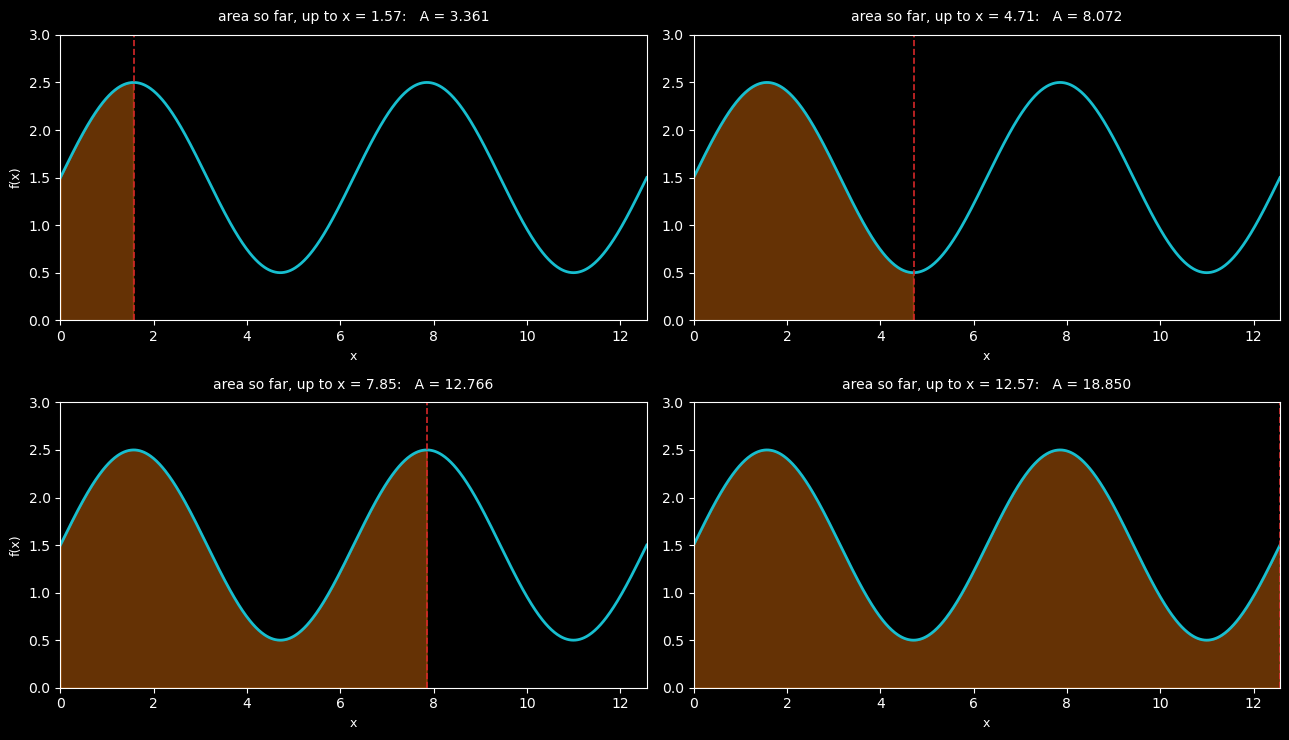

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
for ax, upto in zip(axes.flat, [np.pi/2, np.pi*1.5, np.pi*2.5, np.pi*4]):
    mask = xs <= upto
    ax.plot(xs, f(xs), color="tab:cyan", lw=2)
    ax.fill_between(xs[mask], f(xs[mask]), 0, color="tab:orange", alpha=0.4)
    i = np.argmin(np.abs(xs - upto))
    ax.axvline(upto, color="tab:red", ls="--", lw=1.2)
    ax.set_xlim(0, 4*np.pi); ax.set_ylim(0, 3)
    ax.set_xlabel("x", fontsize=9)
    ax.set_title(f"area so far, up to x = {upto:.2f}:   A = {A[i]:.3f}", pad=10, fontsize=10)
axes[0, 0].set_ylabel("f(x)", fontsize=9)
axes[1, 0].set_ylabel("f(x)", fontsize=9)
plt.tight_layout()
plt.show()

## 2. Differentiate the area — and get the curve back

$A(x)$ is a function, so it has a derivative. Compute it numerically with the central difference from
§3.4 and plot it against the original $f$.

They are **the same curve**.

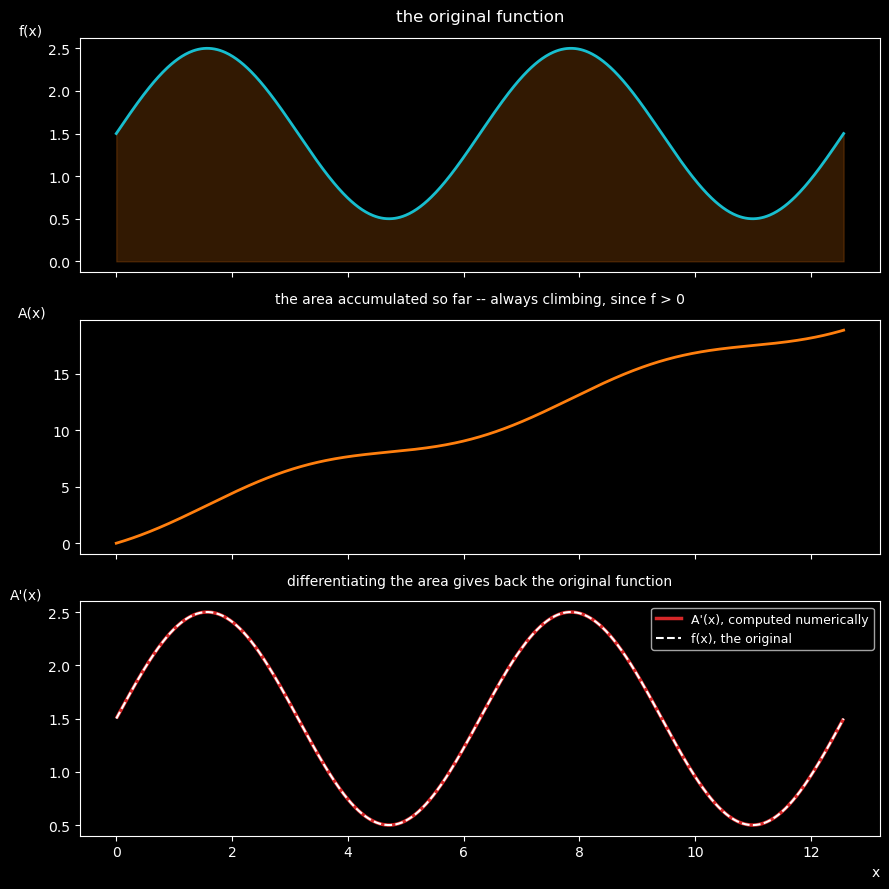

largest disagreement between A'(x) and f(x): 6.18e-05


In [4]:
# central difference of the area-so-far function
dA = (A[2:] - A[:-2]) / (2*dx)
x_mid = xs[1:-1]

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(xs, f(xs), color="tab:cyan", lw=2)
axes[0].fill_between(xs, f(xs), 0, color="tab:orange", alpha=0.2)
axes[0].set_ylabel("f(x)", loc="top", rotation=0)
axes[0].set_title("the original function", pad=12)

axes[1].plot(xs, A, color="tab:orange", lw=2)
axes[1].set_ylabel("A(x)", loc="top", rotation=0)
axes[1].set_title("the area accumulated so far -- always climbing, since f > 0", pad=12, fontsize=10)

axes[2].plot(x_mid, dA, color="tab:red", lw=2.5, label="A'(x), computed numerically")
axes[2].plot(xs, f(xs), "--", color="white", lw=1.5, label="f(x), the original")
axes[2].set_ylabel("A'(x)", loc="top", rotation=0)
axes[2].set_xlabel("x", loc="right")
axes[2].legend(fontsize=9)
axes[2].set_title("differentiating the area gives back the original function", pad=12, fontsize=10)

plt.tight_layout()
plt.show()

print(f"largest disagreement between A'(x) and f(x): {np.max(np.abs(dA - f(x_mid))):.2e}")

Look at the middle panel against the top one. Where $f$ is **large**, $A$ climbs **steeply**. Where $f$
dips toward zero, $A$ nearly levels off. The height of one is the slope of the other — which is exactly
what $A'(x) = f(x)$ says.

## 3. Why: the sliver

The argument fits in a sentence, and it is just the difference quotient from §3.3.

Move $x$ right by a small $h$. The extra area added is a thin sliver: width $h$, height roughly
$f(x)$ (the curve barely changes over such a short span). So

$$A(x + h) - A(x) \approx f(x)\cdot h$$

Divide both sides by $h$:

$$\frac{A(x+h) - A(x)}{h} \approx f(x)$$

The left side is the difference quotient for $A'$. Let $h \to 0$ and the approximation becomes exact:
$A'(x) = f(x)$.

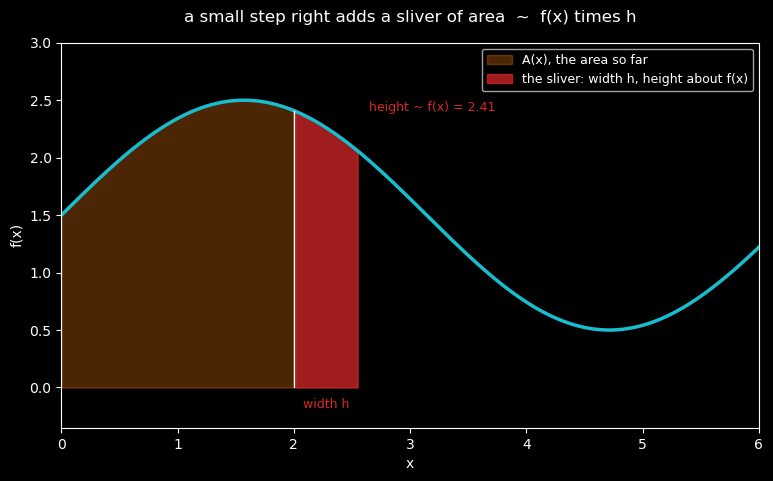

In [5]:
x0 = 2.0
i0 = np.argmin(np.abs(xs - x0))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, f(xs), color="tab:cyan", lw=2.5)
mask = xs <= x0
ax.fill_between(xs[mask], f(xs[mask]), 0, color="tab:orange", alpha=0.3, label="A(x), the area so far")

h_vis = 0.55
sliver = (xs >= x0) & (xs <= x0 + h_vis)
ax.fill_between(xs[sliver], f(xs[sliver]), 0, color="tab:red", alpha=0.75,
                label="the sliver: width h, height about f(x)")
ax.plot([x0, x0], [0, f(x0)], color="white", lw=1)
ax.annotate("width h", ((2*x0 + h_vis)/2, -0.18), color="tab:red", ha="center", fontsize=9)
ax.annotate(f"height ~ f(x) = {f(x0):.2f}", (x0 + h_vis + 0.1, f(x0)), color="tab:red", fontsize=9)

ax.set_xlim(0, 6); ax.set_ylim(-0.35, 3)
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.legend(loc="upper right", fontsize=9)
ax.set_title("a small step right adds a sliver of area  ~  f(x) times h", pad=15)
plt.show()

In [6]:
# the sliver argument, checked numerically at shrinking h
print(f"at x = {x0}, f(x) = {f(x0):.6f}\n")
print(f"{'h':>10} {'[A(x+h) - A(x)] / h':>24}")
print("-" * 36)
for h in [0.5, 0.1, 0.01, 0.001]:
    j = np.argmin(np.abs(xs - (x0 + h)))
    print(f"{h:10.3f} {(A[j] - A[i0]) / (xs[j] - xs[i0]):24.6f}")
print("-" * 36)
print(f"{'-> f(x) =':>10} {f(x0):24.6f}")

at x = 2.0, f(x) = 2.409297

         h      [A(x+h) - A(x)] / h
------------------------------------
     0.500                 2.270462
     0.100                 2.385762
     0.010                 2.407063
     0.001                      nan
------------------------------------
 -> f(x) =                 2.409297


## 4. Part 2: the shortcut

If differentiating an area gives back the function, then running it backwards evaluates areas. Find any
function $F$ whose derivative is $f$ — an **antiderivative** — and

$$\int_a^b f(x)\,dx = F(b) - F(a)$$

This turns an infinite limiting process into **two evaluations and a subtraction**. It is why calculus
became a practical tool rather than a curiosity.

Antiderivatives come from reading the §3.3 rules backwards. Since $\frac{d}{dx}x^3 = 3x^2$, an
antiderivative of $x^2$ is $\frac{x^3}{3}$. In general $\int x^n dx = \frac{x^{n+1}}{n+1}$ for
$n \neq -1$.

In [7]:
# check Part 2 against the Riemann sum from the previous notebook
# note: np.trapz works on NumPy 1.x. It was renamed np.trapezoid in NumPy 2.0,
# so on a newer NumPy swap the name (the arguments are unchanged).
def check(name, f, F, lo, hi):
    exact = F(hi) - F(lo)
    grid = np.linspace(lo, hi, 20001)
    numeric = np.trapz(f(grid), grid)
    print(f"{name:<22} F(b) - F(a) = {exact:11.6f}    Riemann sum = {numeric:11.6f}    "
          f"diff {abs(exact-numeric):.2e}")

print("integral from 0 to 3:")
check("x^2 + 1", lambda x: x**2 + 1, lambda x: x**3/3 + x, 0, 3)
check("x^3", lambda x: x**3, lambda x: x**4/4, 0, 3)
print("\nintegral from 0 to pi:")
check("sin(x)", np.sin, lambda x: -np.cos(x), 0, np.pi)
print("\nintegral from 1 to 2:")
check("1/x", lambda x: 1/x, np.log, 1, 2)
check("exp(x)", np.exp, np.exp, 1, 2)

integral from 0 to 3:
x^2 + 1                F(b) - F(a) =   12.000000    Riemann sum =   12.000000    diff 1.12e-08
x^3                    F(b) - F(a) =   20.250000    Riemann sum =   20.250000    diff 5.06e-08

integral from 0 to pi:
sin(x)                 F(b) - F(a) =    2.000000    Riemann sum =    2.000000    diff 4.11e-09

integral from 1 to 2:
1/x                    F(b) - F(a) =    0.693147    Riemann sum =    0.693147    diff 1.56e-10
exp(x)                 F(b) - F(a) =    4.670774    Riemann sum =    4.670774    diff 9.73e-10


Every one matches. Note the last line: $e^x$ is its own antiderivative, which is why it turns up
everywhere.

Note too that §3.8-1's claim that $\int_0^3 (x^2+1)dx = 12$ is now *proved* rather than asserted:
$F(x) = \frac{x^3}{3} + x$, so $F(3) - F(0) = (9 + 3) - 0 = 12$.

## 5. Summary

- The **area-so-far** function $A(x) = \int_a^x f(t)\,dt$ accumulates area from a fixed start.
- **Part 1:** $A'(x) = f(x)$ — differentiating an accumulated area gives back the original function.
  Differentiation and integration are **inverse operations**.
- The reason is the **sliver**: a small step right adds area $\approx f(x)\cdot h$, so the difference
  quotient of $A$ is $f$.
- **Part 2:** $\int_a^b f(x)\,dx = F(b) - F(a)$ for any antiderivative $F$ — an infinite process
  replaced by two evaluations.
- Antiderivatives are the §3.3 rules read backwards.

Next: integrating when there is no formula — only data points
(`U3-8_Integrals-3_DataPoints`).